# Gradient Boosting Analysis of German Breast Cancer Study Group 2

This example is an overview of how to perform a stacked survival analysis
using the two available time-encoding options of SurvStack as well as a comparison
of the result to a conventional survival analysis using 
[scikit-survival](https://scikit-survival.readthedocs.io/en/stable/index.html).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sksurv.metrics import cumulative_dynamic_auc, integrated_brier_score

## Load data

The scikit-survival package provides multiple survival datasets including the 
German Breast Cancer Study Group 2 dataset which contains 686 samples and 8 
features. None numerical features are converted using the scikit-learn
preprocessing functions.

In [3]:
import sksurv.datasets
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

In [4]:
X, y = sksurv.datasets.load_gbsg2()
event_field, time_field = y.dtype.names

In [5]:
X_enc = X[['age','estrec','pnodes','progrec','tsize']].copy()
X_enc['tgrade'] = \
    OrdinalEncoder(categories=[["I", "II", "III"]]).fit_transform(X[["tgrade"]])
X_enc['horTh'] = \
    OrdinalEncoder(categories=[["no", "yes"]]).fit_transform(X[["horTh"]])
X_enc['menostat'] = \
    OrdinalEncoder(categories=[["Pre", "Post"]]).fit_transform(X[["menostat"]])
X_enc.head()

,age,estrec,pnodes,progrec,tsize,tgrade,horTh,menostat
0,70.0,66.0,3.0,48.0,21.0,1.0,0.0,1.0
1,56.0,77.0,7.0,61.0,12.0,1.0,1.0,1.0
2,58.0,271.0,9.0,52.0,35.0,1.0,1.0,1.0
3,59.0,29.0,4.0,60.0,17.0,1.0,1.0,1.0
4,73.0,65.0,1.0,26.0,35.0,1.0,0.0,1.0


Split dataset into training and testing sets

In [6]:
random_state = 20

X_train, X_test, y_train, y_test = train_test_split(X_enc.values, y, 
                                                    test_size=0.2, 
                                                    stratify=y[event_field], 
                                                    random_state=random_state)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Survival Stacking

In [7]:
from survstack import SurvivalStacker
from sklearn.ensemble import HistGradientBoostingClassifier

In [8]:
def filter_times_on_test(survival_test, estimate, times):
    event_field, time_field = survival_test.dtype.names
    valid_idx = np.where((times > survival_test[time_field].min())&
                         (times < survival_test[time_field].max()))[0]
    valid_times = times[valid_idx]
    valid_estimate = estimate[:, valid_idx]
    return valid_times, valid_estimate

### One-Hot Time Encoding
The `one-hot` `time_encoding` option represents each discrete time point as a separate binary feature, as in the original proposed algorithm. This approach makes no assumptions about the functional form of risk over time and allows the model to learn hazards independently at each time point.

In [9]:
ss_oh = SurvivalStacker(time_encoding='onehot')#, time_step=100)

The training dataset it transformed into stacked survival format. In 
doing so, an additional column is added to X for each observed event time-point 
and rows a duplicated with respect to the number of survivors at each time-point. 

In [10]:
X_oh_train, y_oh_train = ss_oh.fit_transform(X_train, y_train)
X_oh_train.shape, y_oh_train.shape

((76905, 226), (76905,))

The test set is modified differently. In order to calculate the hazard across
all time-points, a duplicate sample for each time-point must be created.
To do so, simply do not provide `y` to the `.transform()` function.
However, to maintain consitancy, a None value is returned as the second
values of the tuple and can be discarded. 

In [11]:
X_oh_test, _ = ss_oh.transform(X_test)
X_oh_test.shape

(30084, 226)

Train the RandomForestClassifier on the stacked surival data

In [12]:
%%time
rfc_oh = HistGradientBoostingClassifier(
    max_iter=10_000,
    max_depth=3, 
    max_features=0.3,
    early_stopping=True,
    n_iter_no_change=20
)
_ = rfc_oh.fit(X_oh_train, y_oh_train)

CPU times: user 1min 32s, sys: 1.07 s, total: 1min 33s
Wall time: 5.61 s


Predict the class probabilities for the test data and extract
the probability of an event (class 1). Convert this to a survival function.

In [13]:
test_oh_estimates = rfc_oh.predict_proba(X_oh_test)[:,1]
test_oh_surv = ss_oh.predict_survival_function(test_oh_estimates)

test_oh_cmhz = ss_oh.predict_cumulative_hazard_function(test_oh_estimates)
test_oh_cmhz_filt, test_oh_times_filter = ss_oh.filter_prediction(y_test, test_oh_cmhz)

We examine the predictive power of the models using the cumulative/dynamic
AUC method provided in scikit-survival.

Calculate the cumulative/dynamic AUC

In [14]:
cdauc_oh, mauc_oh = cumulative_dynamic_auc(survival_train=y_train,
                                  survival_test=y_test,
                                  estimate=test_oh_cmhz_filt,
                                  times=test_oh_times_filter)
ibs_oh = integrated_brier_score(survival_train=y_train,
                                survival_test=y_test,
                                estimate=test_oh_surv,
                                times=ss_oh.times
                               )
print(f"Mean AUC = {mauc_oh:0.3f}\nIBS = {ibs_oh:0.3f}")

Mean AUC = 0.804
IBS = 0.161


## Class Interface (Continuous)
The recommended interface for this package is the SurvivalStacker class. The will determine and save
the time points on which the survial analysis is conducted.

In [15]:
ss_ct = SurvivalStacker(time_encoding='continuous')

The training dataset it transformed into stacked survival format. In 
doing so, an additional column is added to X for each observed event time-point 
and rows a duplicated with respect to the number of survivors at each time-point. 

In [16]:
X_ct_train, y_ct_train = ss_ct.fit_transform(X_train, y_train)
X_ct_train.shape, y_ct_train.shape

((76905, 9), (76905,))

The test set is modified differently. In order to calculate the hazard across
all time-points, a duplicate sample for each time-point must be created.
To do so, simply do not provide `y` to the `.transform()` function.
However, to maintain consitancy, a None value is returned as the second
values of the tuple and can be discarded. 

In [17]:
X_ct_test, _ = ss_ct.transform(X_test)
X_ct_test.shape

(30084, 9)

Train the RandomForestClassifier on the stacked surival data

In [18]:
%%time
rfc_ct = HistGradientBoostingClassifier(
    max_iter=10_000,
    max_depth=3, 
    max_features=0.3,
    early_stopping=True,
    n_iter_no_change=20
)
_ = rfc_ct.fit(X_ct_train, y_ct_train)

CPU times: user 1.63 s, sys: 19.6 ms, total: 1.65 s
Wall time: 152 ms


Predict the class probabilities for the test data and extract
the probaility of an event (class 1). Convert this to a cummulative
hazard function.

In [19]:
test_ct_estimates = rfc_ct.predict_proba(X_ct_test)[:,1]
test_ct_surv = ss_ct.predict_survival_function(test_ct_estimates)

test_ct_cmhz = ss_ct.predict_cumulative_hazard_function(test_ct_estimates)
test_ct_cmhz_filt, test_ct_times_filter = ss_ct.filter_prediction(y_test, test_ct_cmhz)

We examine the predictive power of the models using the cumulative/dynamic
AUC method provided in scikit-survival.

Calculate the cumulative/dynamic AUC

In [20]:
cdauc_ct, mauc_ct = cumulative_dynamic_auc(survival_train=y_train, 
                                  survival_test=y_test, 
                                  estimate=test_ct_cmhz_filt, 
                                  times=test_ct_times_filter)
ibs_ct = integrated_brier_score(survival_train=y_train,
                                survival_test=y_test,
                                estimate=test_ct_surv,
                                times=ss_ct.times
                               )
print(f"Mean AUC = {mauc_ct:0.3f}\nIBS = {ibs_ct:0.3f}")

Mean AUC = 0.800
IBS = 0.171


## scikit-survival GradientBoostingSurvival
For comparison, we can do the same analysis on the original data
using a gradient-boosted Cox proportional hazards model for censored 
survival data as provided by scikit-survival.

In [21]:
from sksurv.ensemble import GradientBoostingSurvivalAnalysis

In [22]:
%%time
rsf = GradientBoostingSurvivalAnalysis(
    n_estimators=10_000,
    max_depth=3,
    max_features=0.3,
    n_iter_no_change=20
)
_ = rsf.fit(X_train, y_train)

CPU times: user 472 ms, sys: 0 ns, total: 472 ms
Wall time: 470 ms


In [23]:
# Filter on valid times
event_times = y_test["time"][y_test["cens"]].copy()
eval_times = rsf.unique_times_[(rsf.unique_times_ >= event_times.min())&(rsf.unique_times_ <= event_times.max())]

# predict survival function for each sample
rsf_surv = rsf.predict_survival_function(X_test)
rsf_cmhz = rsf.predict_cumulative_hazard_function(X_test)

# convert list of StepFunction objects to 2D array: n_samples x n_eval_times
pred_surv = np.vstack([sf(eval_times) for sf in rsf_surv])
pred_hzrd = np.vstack([sf(eval_times) for sf in rsf_cmhz])

# now you can call cumulative_dynamic_auc
gbs_cdauc, gbs_mauc = cumulative_dynamic_auc(
    survival_train=y_train,
    survival_test=y_test,
    estimate=pred_hzrd,  # hazard estimate
    times=eval_times
)
rsf_ibs = integrated_brier_score(survival_train=y_train,
                                 survival_test=y_test,
                                 estimate=pred_surv,
                                 times=eval_times
                                )
print(f"Mean AUC = {gbs_mauc:0.3f}\nIBS = {rsf_ibs:0.3f}")

Mean AUC = 0.789
IBS = 0.166


## Plotting the Results

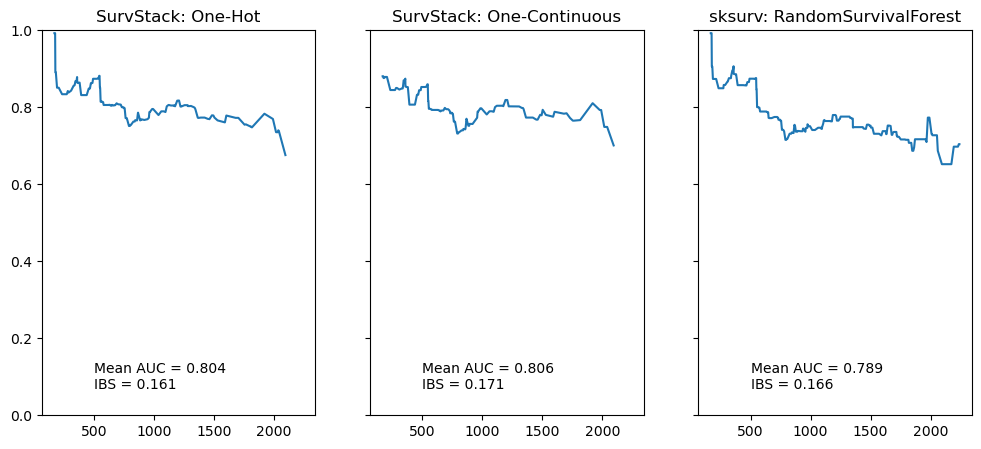

In [24]:
fig, axs = plt.subplots(ncols=3, sharex=True, sharey=True, figsize=(12,5))
sns.lineplot(y=cdauc_oh, x=test_oh_times_filter, ax=axs[0])
axs[0].set_title("SurvStack: One-Hot")
axs[0].text(500, 0.1, f"Mean AUC = {mauc_oh:0.3f}\nIBS = {ibs_oh:0.3f}", ha = "left", va = "center")
sns.lineplot(y=cdauc_ct, x=test_ct_times_filter, ax=axs[1])
axs[1].set_title("SurvStack: One-Continuous")
axs[1].text(500, 0.1, f"Mean AUC = {np.nanmean(cdauc_ct):0.3f}\nIBS = {ibs_ct:0.3f}", ha = "left", va = "center")
sns.lineplot(y=gbs_cdauc, x=eval_times, ax=axs[2])
axs[2].set_title("sksurv: RandomSurvivalForest")
axs[2].text(500, 0.1, f"Mean AUC = {gbs_mauc:0.3f}\nIBS = {rsf_ibs:0.3f}", ha = "left", va = "center")
_ = axs[0].set(ylim=(0, 1))